In [1]:
# ===============================
# Core Libraries
# ===============================
import numpy as np
import pandas as pd

# ===============================
# Visualization
# ===============================
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# ===============================
# Preprocessing & Splitting
# ===============================
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler

# ===============================
# Regression Models
# ===============================
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# ===============================
# Evaluation Metrics
# ===============================
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
#some settings for visualization
sns.set_theme(
    context="notebook",
    style="whitegrid",
    palette="deep"
)

# Discrete colors for categories
cats = sns.color_palette("viridis", n_colors=5)

# Continuous colormap for heatmaps and densities
viridis_cmap = sns.color_palette("viridis", as_cmap=True)

# Global defaults via Matplotlib rcParams
plt.rcParams["figure.figsize"] = (7, 4)    # width, height in inches
plt.rcParams["figure.dpi"] = 150  

## Importing the data and initial sanity checks

In [3]:
df = pd.read_csv('energy_efficiency_data.csv')
df.head(5)

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [4]:
data = df.copy()

In [5]:
print(data.isnull().sum())
print("--------")
print(data.isna().sum())

Relative_Compactness         0
Surface_Area                 0
Wall_Area                    0
Roof_Area                    0
Overall_Height               0
Orientation                  0
Glazing_Area                 0
Glazing_Area_Distribution    0
Heating_Load                 0
Cooling_Load                 0
dtype: int64
--------
Relative_Compactness         0
Surface_Area                 0
Wall_Area                    0
Roof_Area                    0
Overall_Height               0
Orientation                  0
Glazing_Area                 0
Glazing_Area_Distribution    0
Heating_Load                 0
Cooling_Load                 0
dtype: int64


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Relative_Compactness       768 non-null    float64
 1   Surface_Area               768 non-null    float64
 2   Wall_Area                  768 non-null    float64
 3   Roof_Area                  768 non-null    float64
 4   Overall_Height             768 non-null    float64
 5   Orientation                768 non-null    int64  
 6   Glazing_Area               768 non-null    float64
 7   Glazing_Area_Distribution  768 non-null    int64  
 8   Heating_Load               768 non-null    float64
 9   Cooling_Load               768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


In [7]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Relative_Compactness,768.0,0.764167,0.105777,0.62,0.6825,0.75,0.8300,0.98
Surface_Area,768.0,671.708333,88.086116,514.50,606.3750,673.75,741.1250,808.50
Wall_Area,768.0,318.500000,43.626481,245.00,294.0000,318.50,343.0000,416.50
Roof_Area,768.0,176.604167,45.165950,110.25,140.8750,183.75,220.5000,220.50
Overall_Height,768.0,5.250000,1.751140,3.50,3.5000,5.25,7.0000,7.00
Orientation,768.0,3.500000,1.118763,2.00,2.7500,3.50,4.2500,5.00
Glazing_Area,768.0,0.234375,0.133221,0.00,0.1000,0.25,0.4000,0.40
Glazing_Area_Distribution,768.0,2.812500,1.550960,0.00,1.7500,3.00,4.0000,5.00
Heating_Load,768.0,22.307201,10.090196,6.01,12.9925,18.95,31.6675,43.10
Cooling_Load,768.0,24.587760,9.513306,10.90,15.6200,22.08,33.1325,48.03


In [8]:
#cheking unique values and understanding cardinality
def check_unique(col_list):
    for col in col_list:
        print(f"{col} has {data[col].unique()}")
        print("--------------")

check_unique(["Orientation","Glazing_Area","Glazing_Area_Distribution"])

Orientation has [2 3 4 5]
--------------
Glazing_Area has [0.   0.1  0.25 0.4 ]
--------------
Glazing_Area_Distribution has [0 1 2 3 4 5]
--------------


**Initial Conclusions:**
- Data has no empty / null values
- We can detect some categorical attributes as seen above
- We have two targets
- Nothing initially suspicious or requires extra attention at the beginning

We can proceed to EDA now

## Exploratory Data Analysis

### Univariate Analysis

**Target Variables Distribution**

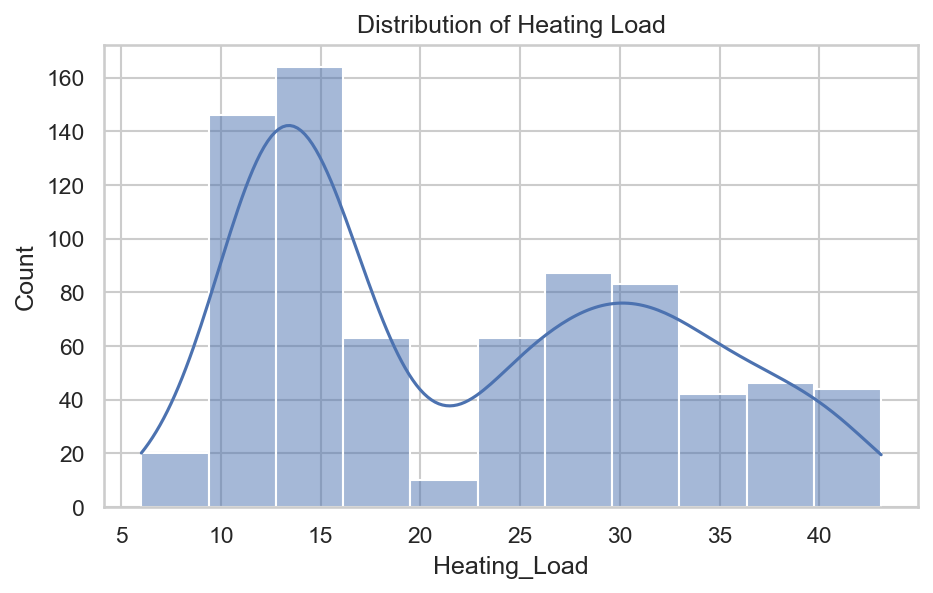

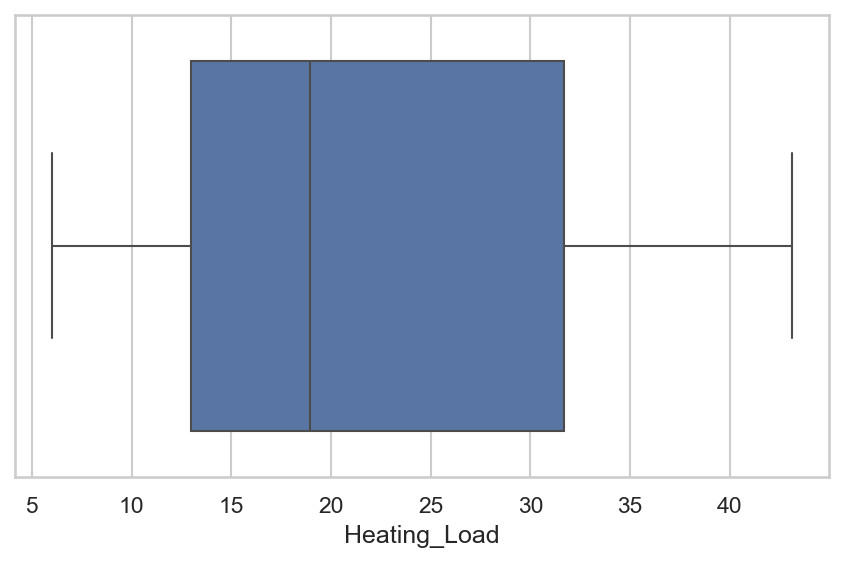

In [9]:
sns.histplot(data['Heating_Load'], kde=True)
plt.title("Distribution of Heating Load")
plt.show()

sns.boxplot(x=data['Heating_Load'])
plt.show()

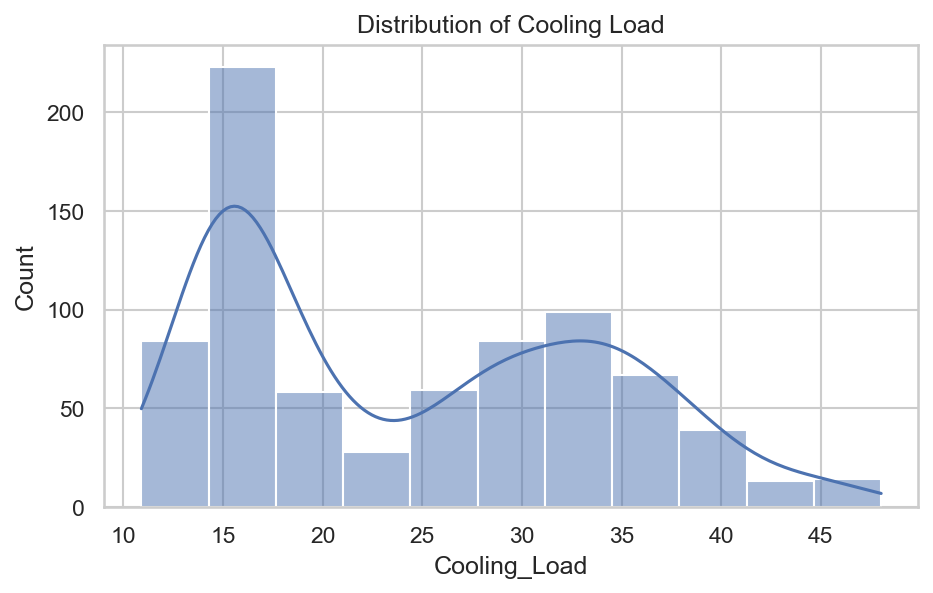

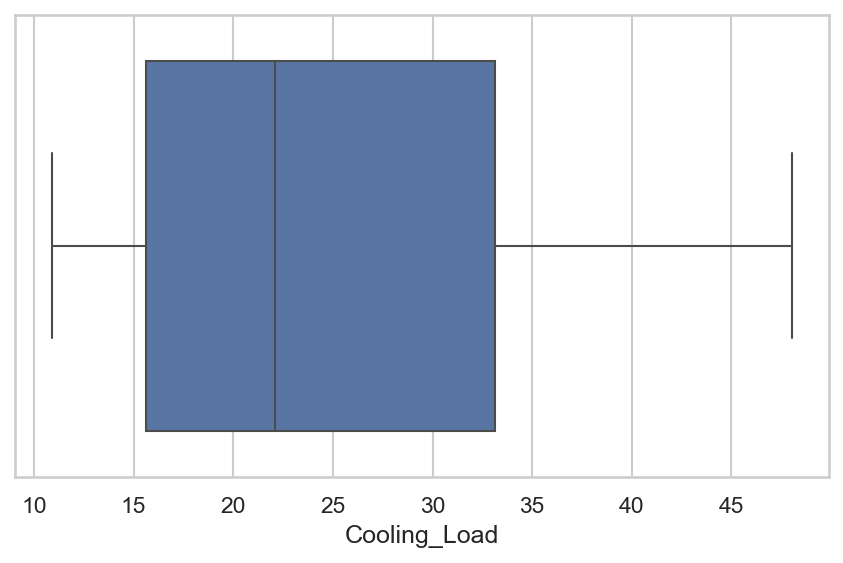

In [10]:
sns.histplot(data['Cooling_Load'], kde=True)
plt.title("Distribution of Cooling Load")
plt.show()

sns.boxplot(x=data['Cooling_Load'])
plt.show()

**Continuous Features Distribution**

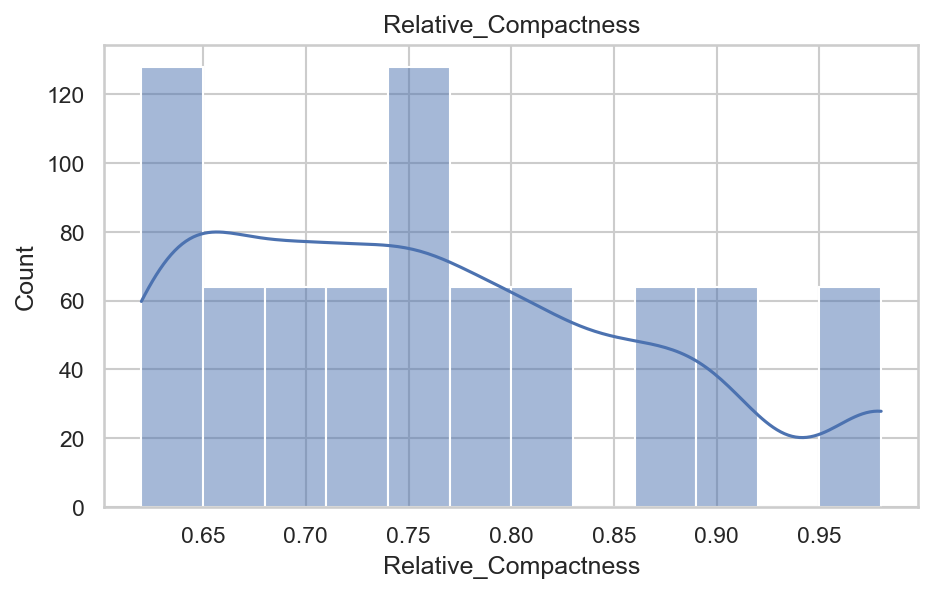

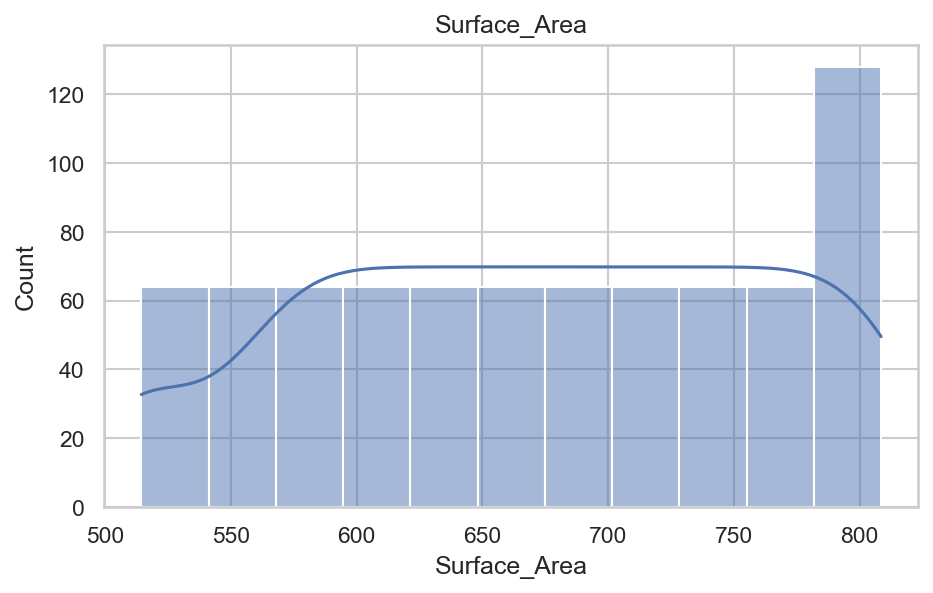

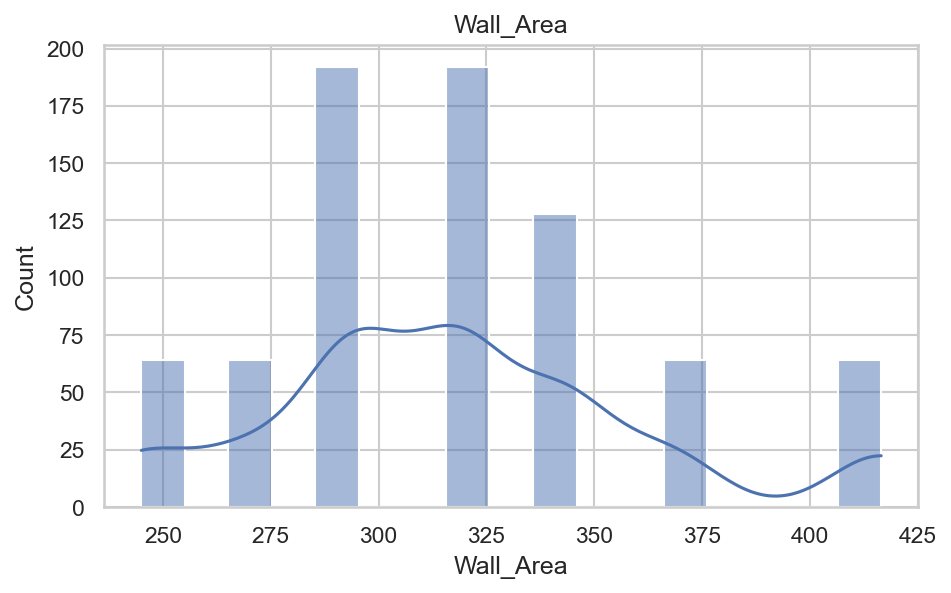

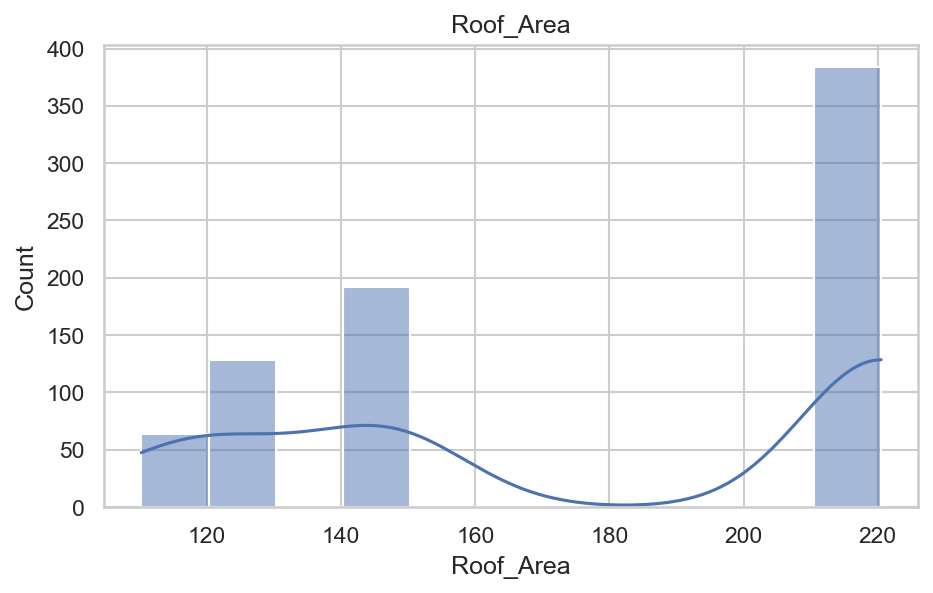

In [11]:
col_list = ["Relative_Compactness","Surface_Area","Wall_Area","Roof_Area"]
for col in col_list:
    sns.histplot(data[col], kde=True)
    plt.title(col)
    plt.xlabel(col)
    plt.show()

**Exploring categorical features**

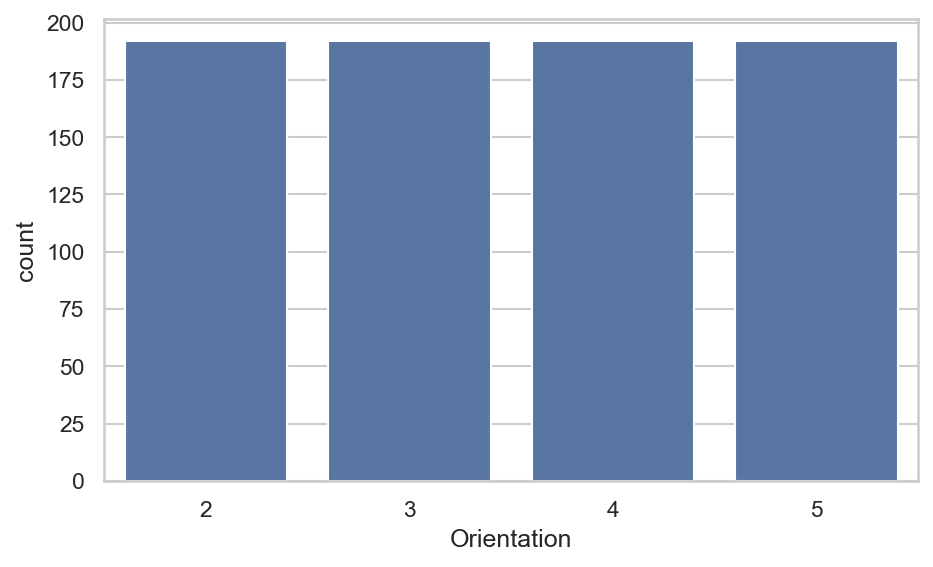

In [12]:
sns.countplot(x=data['Orientation']);

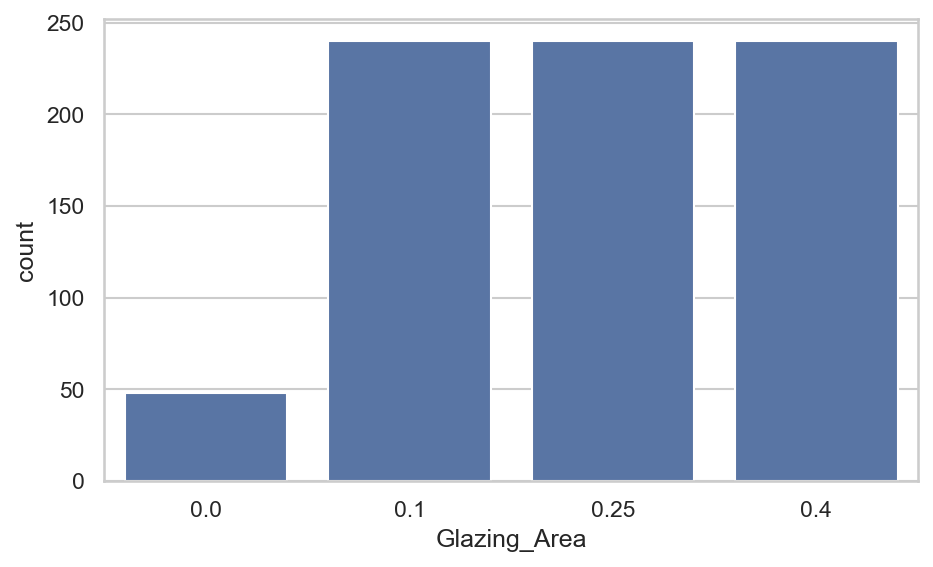

In [13]:
sns.countplot(x=data['Glazing_Area']);

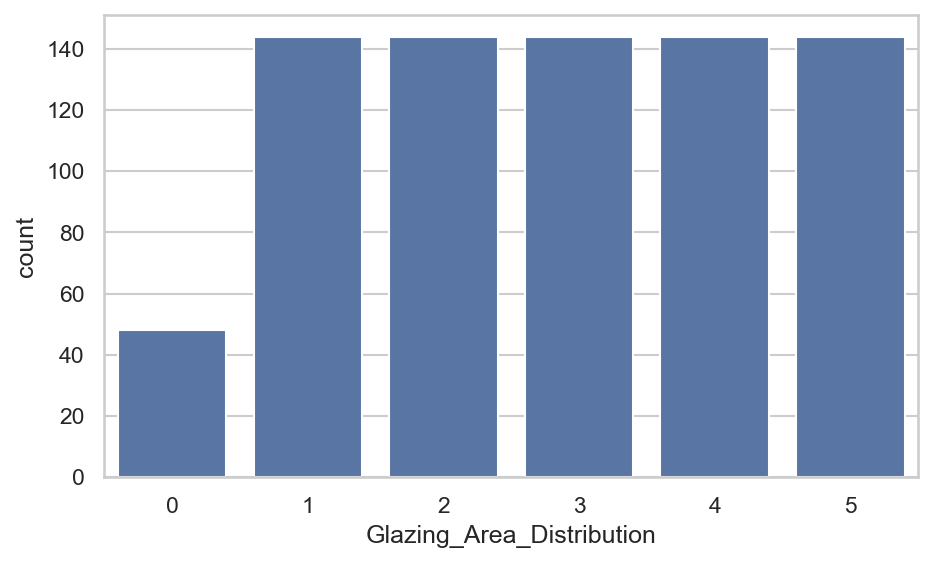

In [14]:
sns.countplot(x=data['Glazing_Area_Distribution']);

In [15]:
data.skew()

Relative_Compactness         0.495513
Surface_Area                -0.125131
Wall_Area                    0.533417
Roof_Area                   -0.162764
Overall_Height               0.000000
Orientation                  0.000000
Glazing_Area                -0.060254
Glazing_Area_Distribution   -0.088689
Heating_Load                 0.360449
Cooling_Load                 0.395992
dtype: float64

**Checking Outliers**

In [16]:
def detect_outliers_iqr(df):
    outlier_summary = []

    for col in df.select_dtypes(include=['float64', 'int64']).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

        outlier_summary.append({
            'Feature': col,
            'Lower Bound': round(lower_bound, 2),
            'Upper Bound': round(upper_bound, 2),
            'Outlier Count': outliers.shape[0]
        })

    return pd.DataFrame(outlier_summary)

In [17]:
outlier_report = detect_outliers_iqr(data)
outlier_report

,Feature,Lower Bound,Upper Bound,Outlier Count
0,Relative_Compactness,0.46,1.05,0
1,Surface_Area,404.25,943.25,0
2,Wall_Area,220.50,416.50,0
3,Roof_Area,21.44,339.94,0
4,Overall_Height,-1.75,12.25,0
5,Orientation,0.50,6.50,0
6,Glazing_Area,-0.35,0.85,0
7,Glazing_Area_Distribution,-1.62,7.38,0
8,Heating_Load,-15.02,59.68,0
9,Cooling_Load,-10.65,59.40,0


### Bivariate Analysis

In [18]:
def plot_feature_vs_targets(df, features, target1='Heating_Load', target2='Cooling_Load'):
    
    for feature in features:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        
        # Feature vs Heating Load
        sns.boxplot(
            x=df[feature],
            y=df[target1],
            ax=axes[0]
        )
        axes[0].set_title(f'{feature} vs {target1}')
        
        # Feature vs Cooling Load
        sns.boxplot(
            x=df[feature],
            y=df[target2],
            ax=axes[1]
        )
        axes[1].set_title(f'{feature} vs {target2}')
        
        plt.tight_layout()
        plt.show()

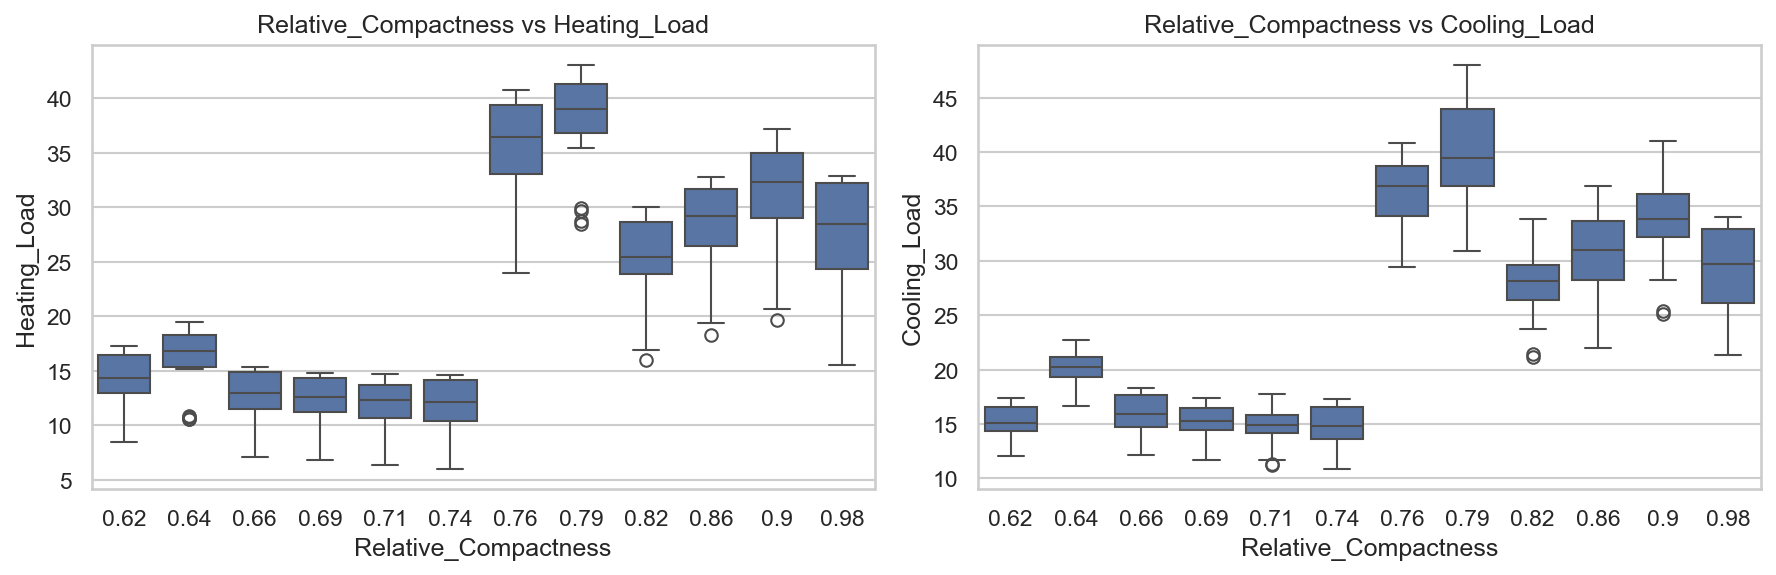

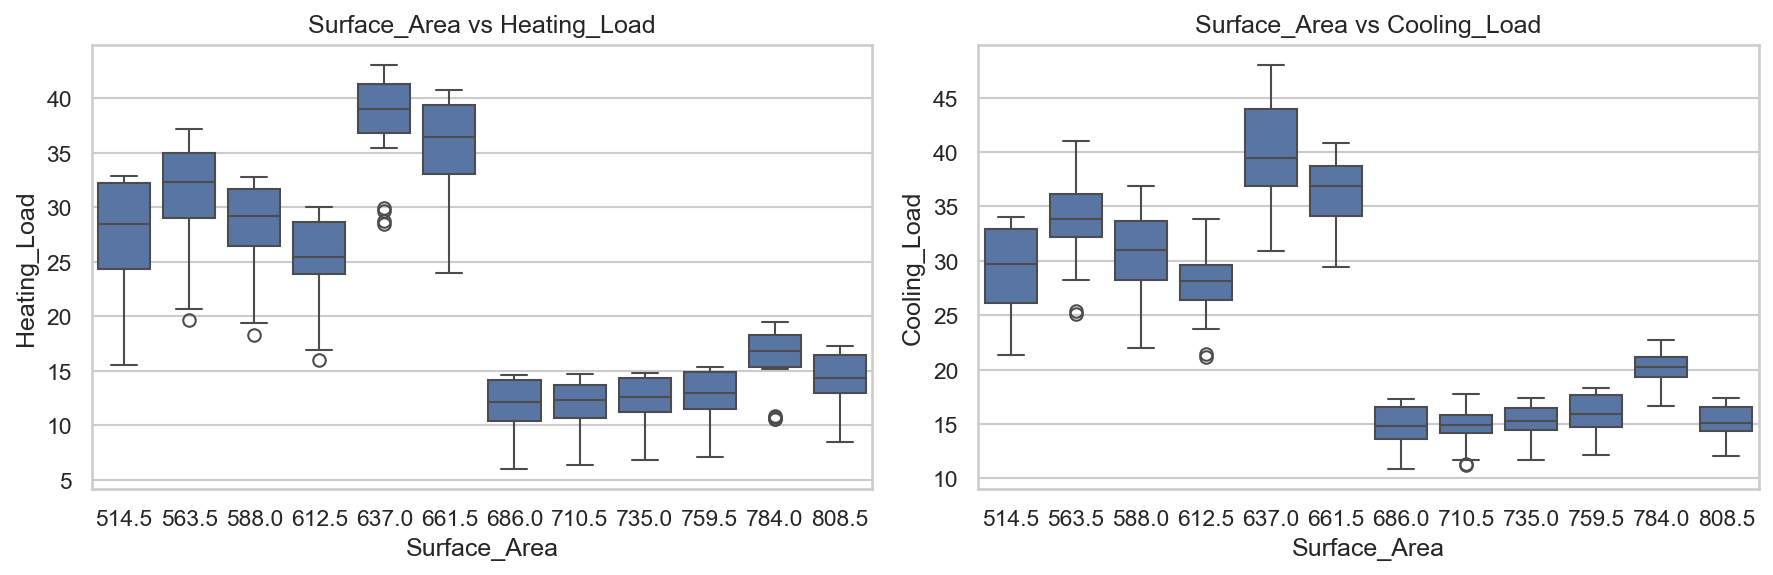

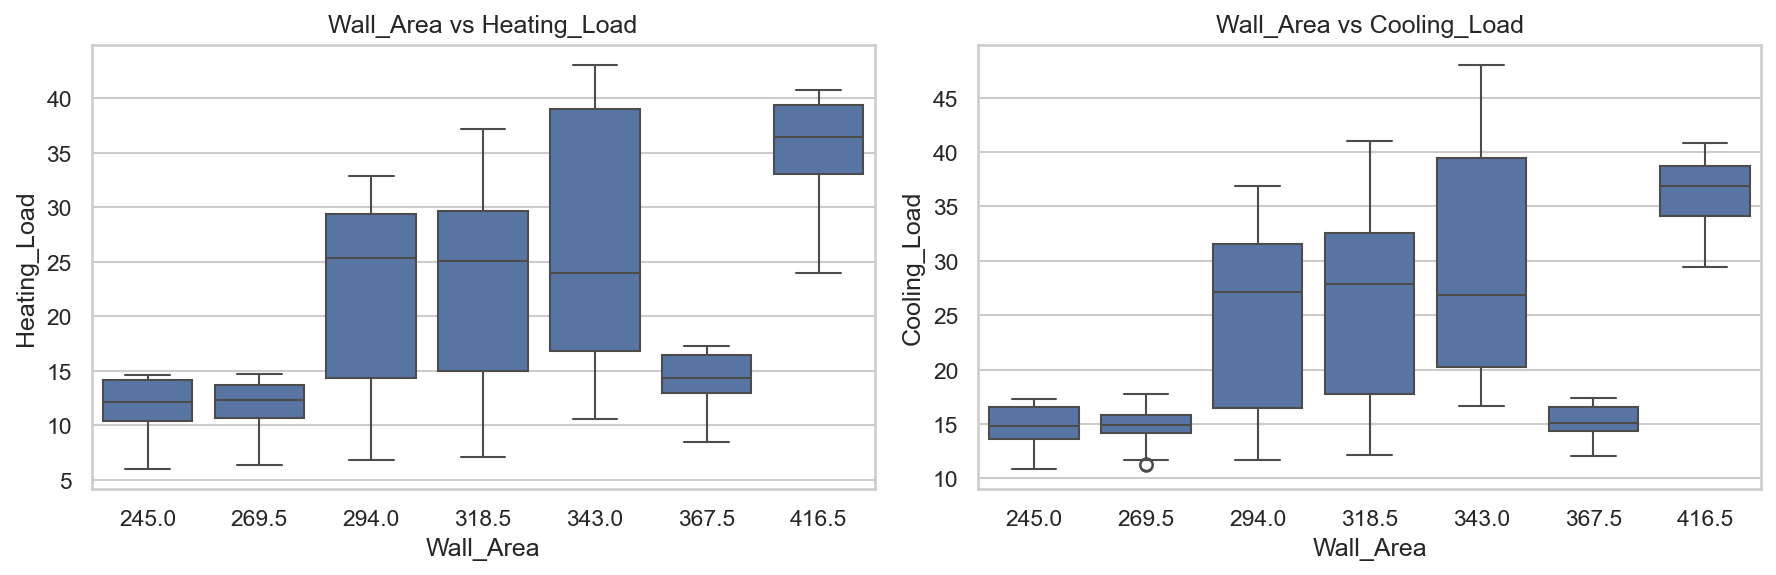

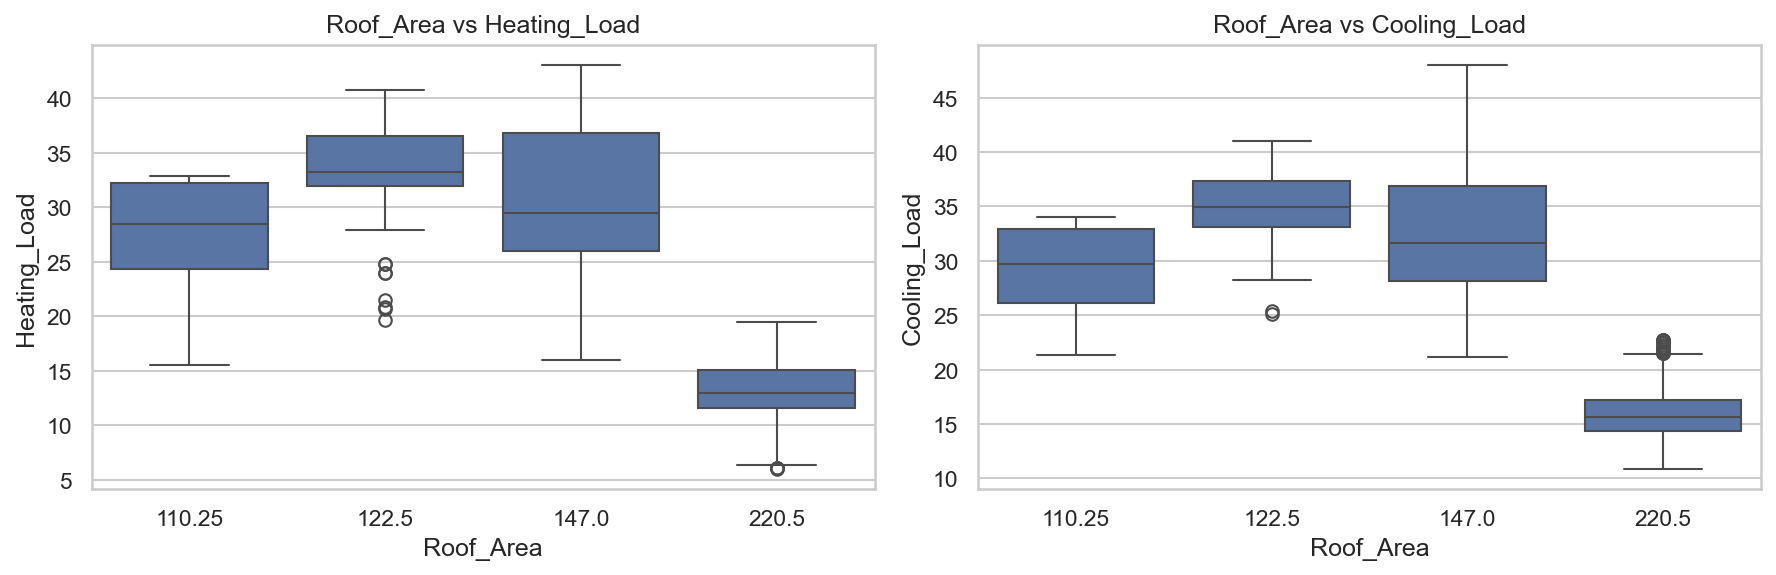

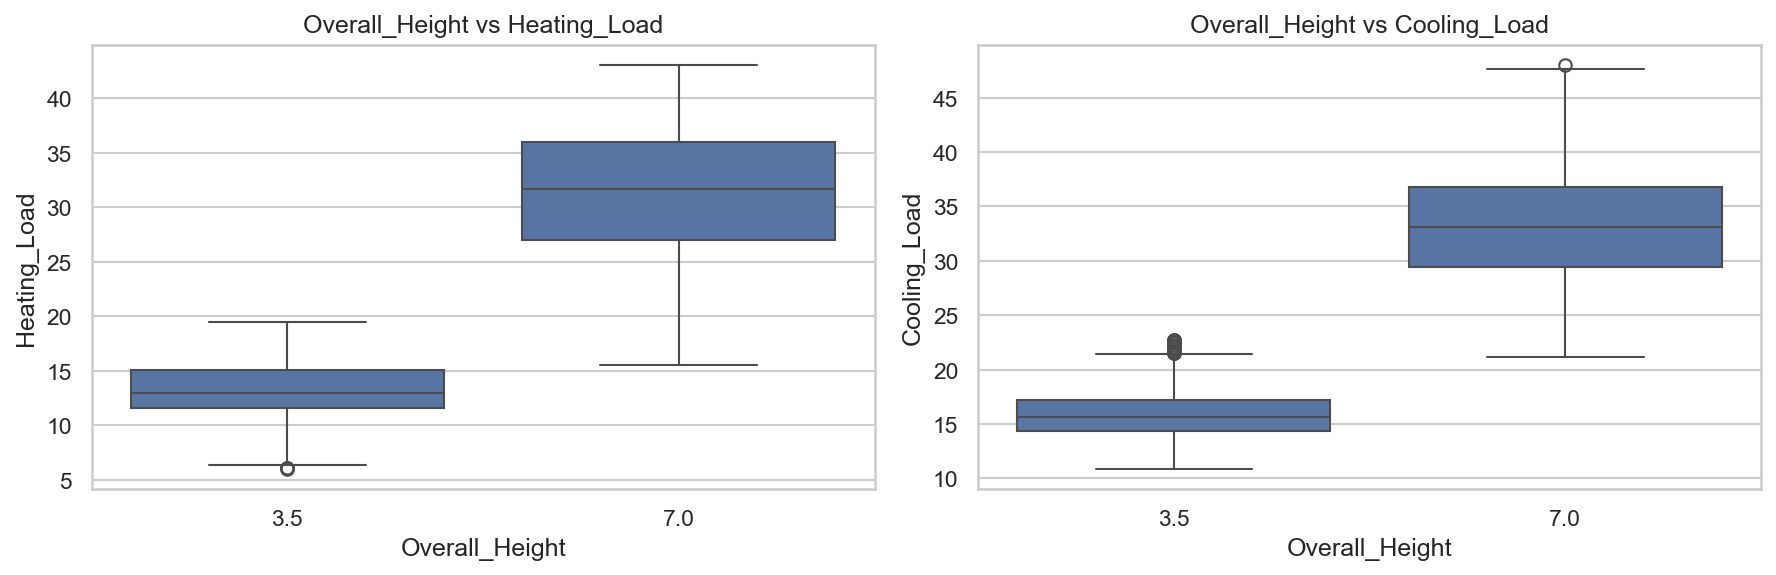

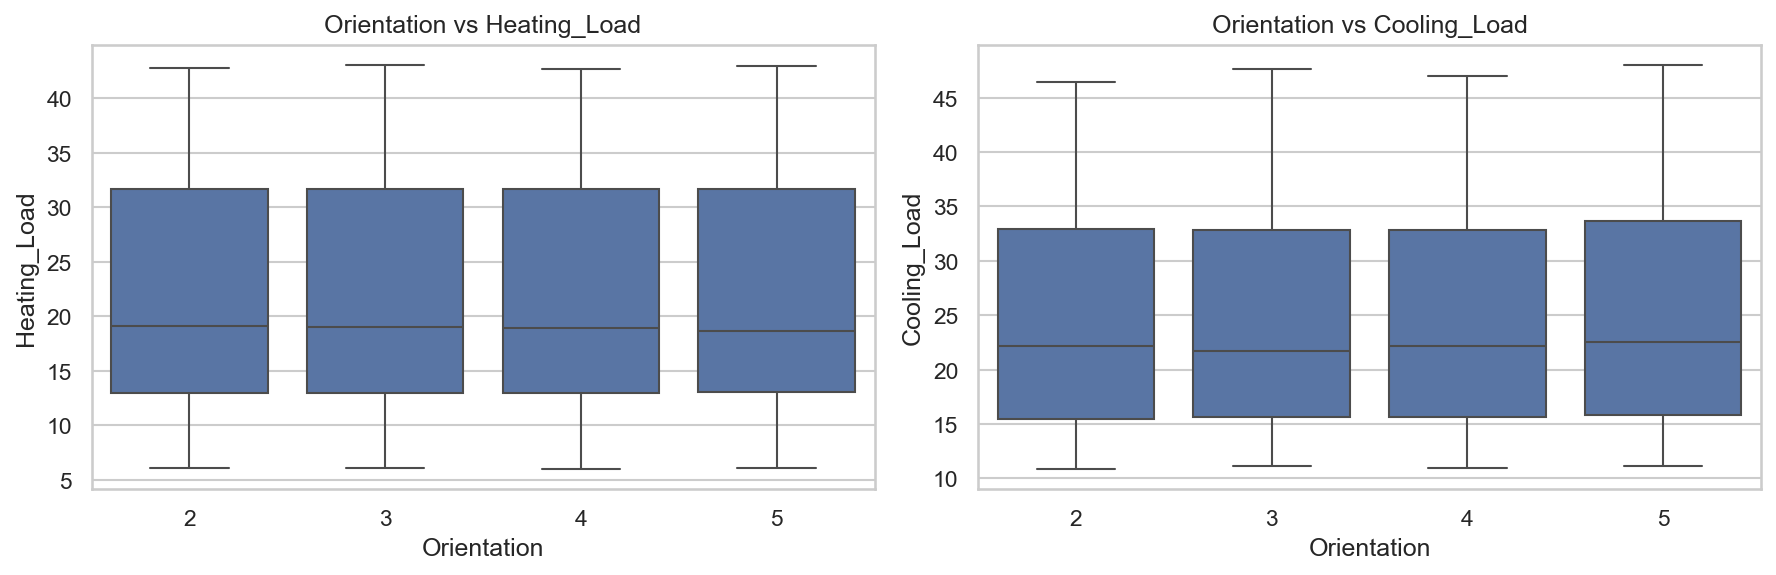

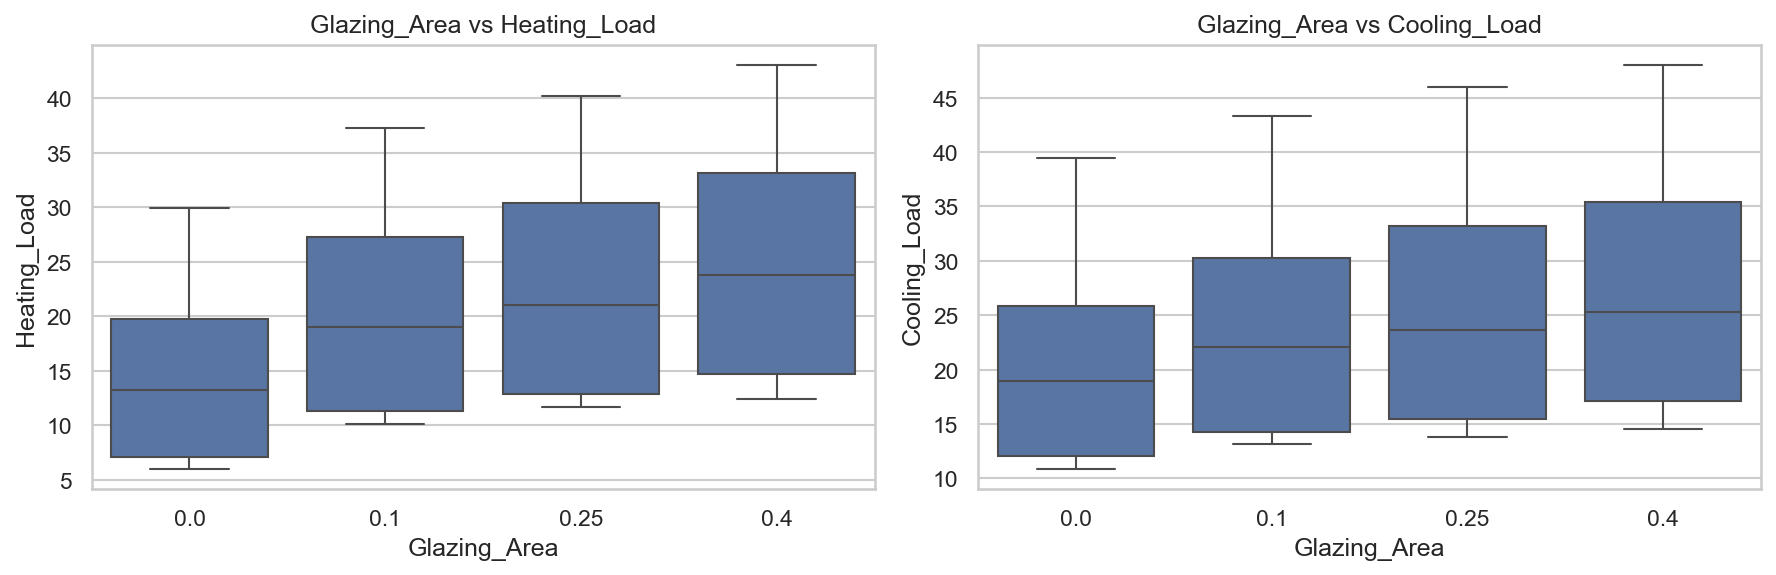

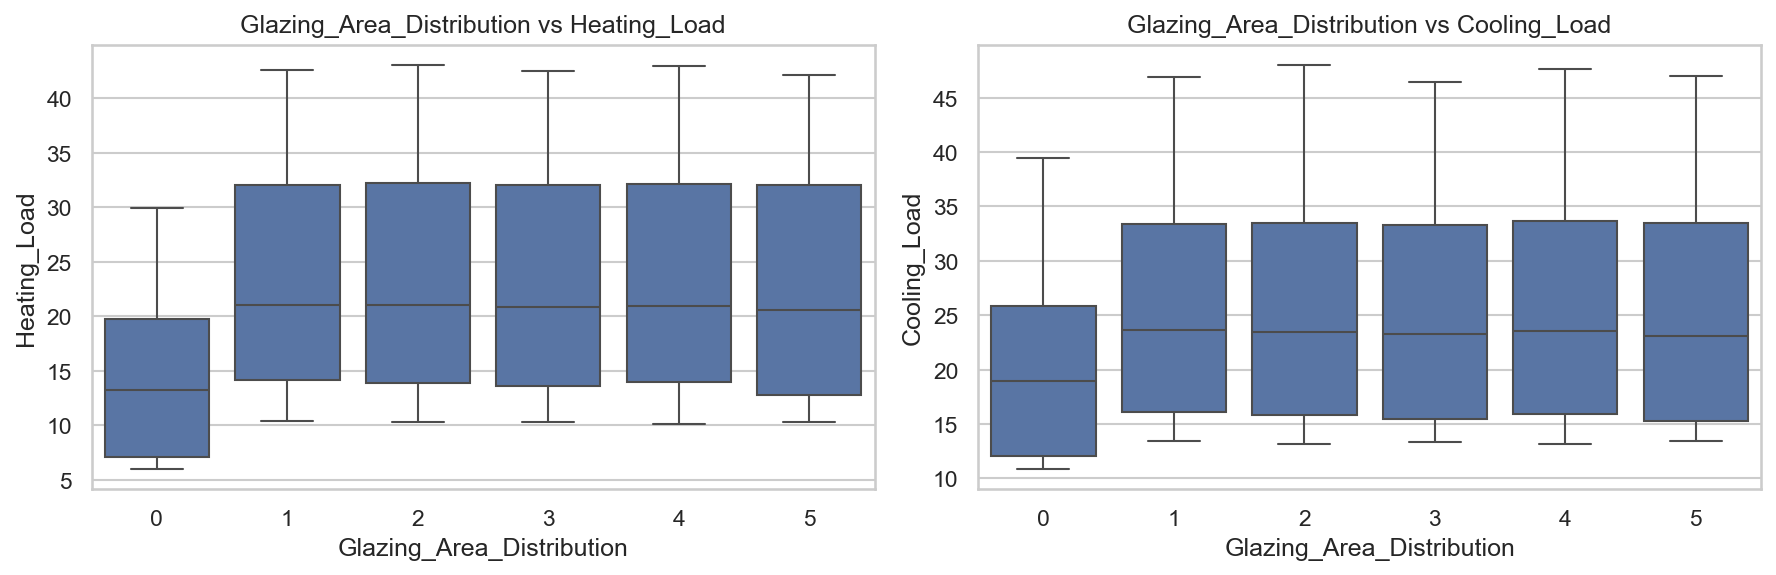

In [19]:
features = [
    'Relative_Compactness',
    'Surface_Area',
    'Wall_Area',
    'Roof_Area',
    'Overall_Height',
    'Orientation',
    'Glazing_Area',
    'Glazing_Area_Distribution'
]

plot_feature_vs_targets(data, features)

**Correlation Analysis**

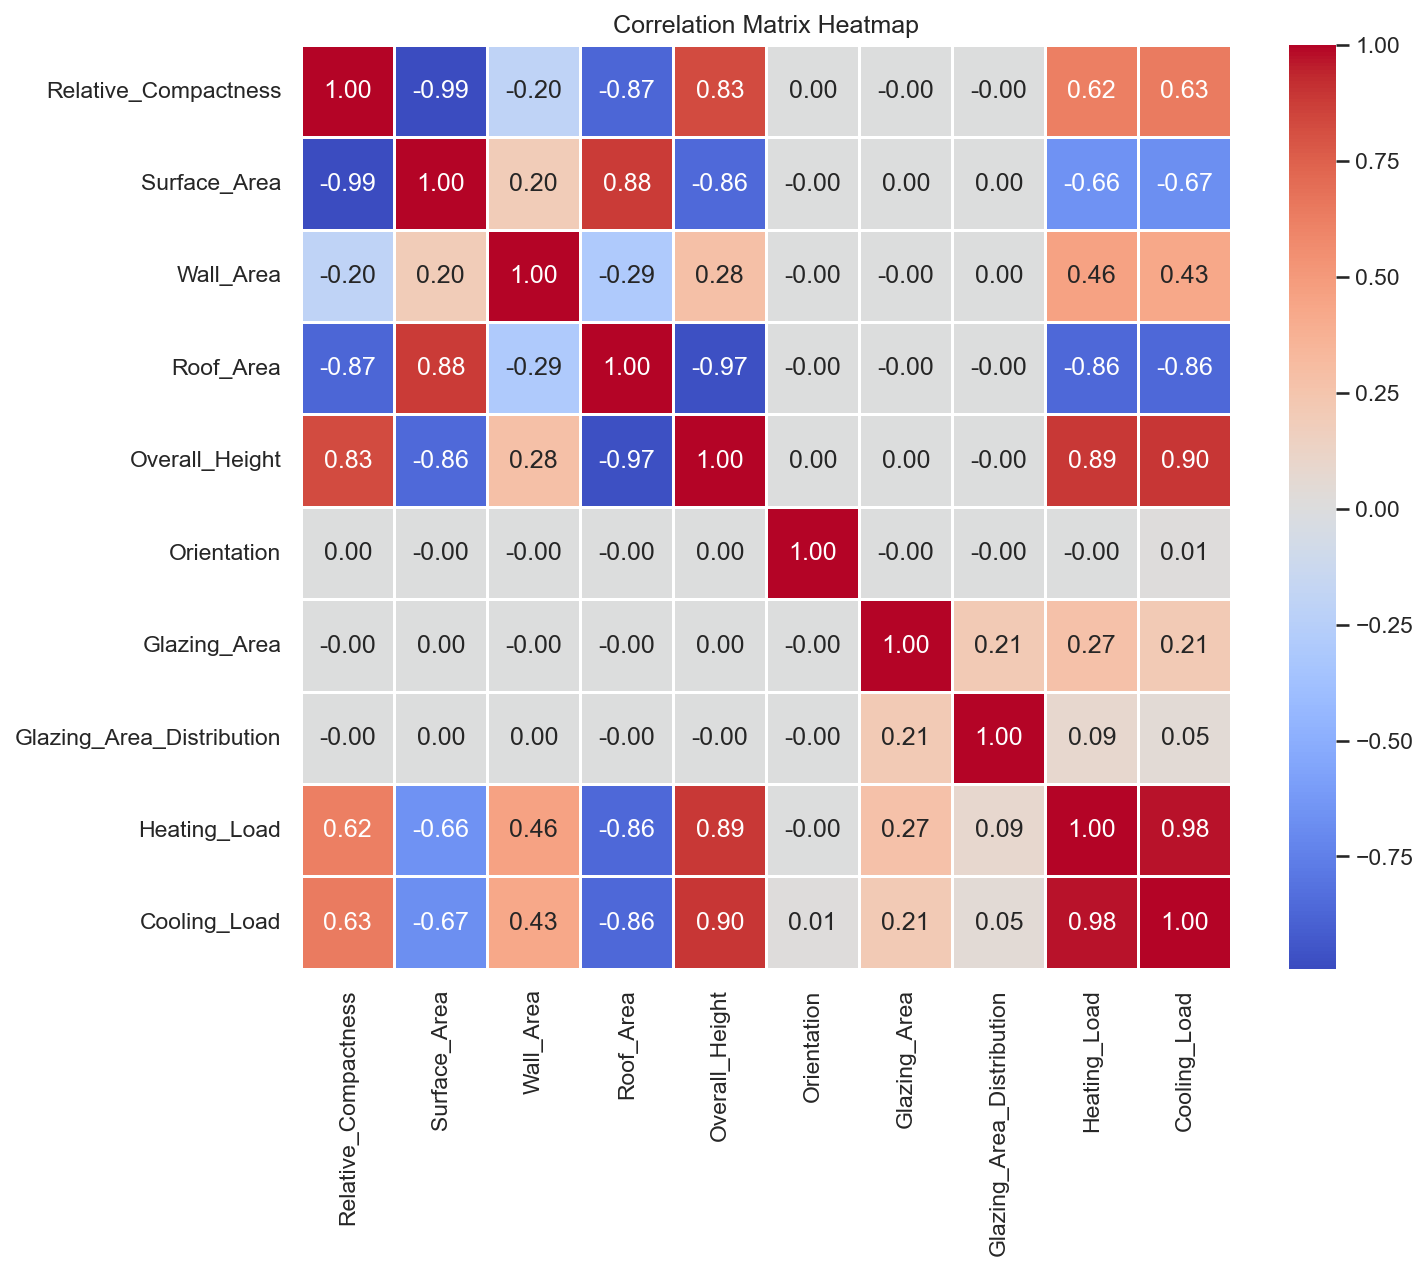

In [20]:
plt.figure(figsize=(10,8))

corr_matrix = data.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Matrix Heatmap")
#plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

In [21]:
# Compute full correlation matrix
corr_matrix = df.corr()

# Select only correlations with the two targets
target_corr = corr_matrix[['Heating_Load', 'Cooling_Load']]

# Remove the targets themselves from rows
target_corr = target_corr.drop(['Heating_Load', 'Cooling_Load'])

# Sort by Heating_Load correlation (optional but cleaner)
target_corr = target_corr.sort_values(by='Heating_Load', ascending=False)

target_corr

,Heating_Load,Cooling_Load
Overall_Height,0.889431,0.895785
Relative_Compactness,0.622272,0.634339
Wall_Area,0.455671,0.427117
Glazing_Area,0.269841,0.207505
Glazing_Area_Distribution,0.087368,0.050525
Orientation,-0.002587,0.014290
Surface_Area,-0.658120,-0.672999
Roof_Area,-0.861828,-0.862547


## Pre-Processing

**Multicollinearity Treatment** - Only to be applied for Linear Models

In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(df, features):
    """
    Calculates VIF for selected features.
    Returns a sorted DataFrame.
    """
    X = df[features].copy()
    
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
    
    vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)
    
    return vif_data

In [23]:
features = [
    'Relative_Compactness',
    'Surface_Area',
    'Wall_Area',
    'Roof_Area',
    'Overall_Height',
    'Orientation',
    'Glazing_Area',
    'Glazing_Area_Distribution'
]

vif_results = calculate_vif(data, features)
vif_results

C:\Users\wassi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
0,Surface_Area,inf
1,Wall_Area,inf
2,Roof_Area,inf
3,Relative_Compactness,168.948751
4,Overall_Height,134.035782
5,Orientation,10.796725
6,Glazing_Area_Distribution,4.496320
7,Glazing_Area,4.293656


In [24]:
reduced_features = [
    'Overall_Height',
    'Wall_Area',
    'Orientation',
    'Glazing_Area',
    'Glazing_Area_Distribution'
]

calculate_vif(data, reduced_features)

,Feature,VIF
0,Wall_Area,21.016851
1,Overall_Height,10.706893
2,Orientation,9.296871
3,Glazing_Area_Distribution,4.357974
4,Glazing_Area,4.173322


In [25]:
final_linear_features = [
    'Overall_Height',
    'Glazing_Area',
    'Glazing_Area_Distribution',
    'Orientation'
]
calculate_vif(data, final_linear_features)

,Feature,VIF
0,Orientation,6.578266
1,Overall_Height,6.410091
2,Glazing_Area_Distribution,4.107212
3,Glazing_Area,3.955207


**Splitting the Data**

In [26]:
X_linear = df[final_linear_features]
X_tree = df.drop(columns=['Heating_Load', 'Cooling_Load'])

y = df[['Heating_Load', 'Cooling_Load']]

X_train_lin, X_test_lin, y_train, y_test = train_test_split(
    X_linear, y, test_size=0.2, random_state=42
)

X_train_tree, X_test_tree, _, _ = train_test_split(
    X_tree, y, test_size=0.2, random_state=42
)

In [27]:
print(X_train_lin.head(5))
print(X_test_lin.head(5))

     Overall_Height  Glazing_Area  Glazing_Area_Distribution  Orientation
60              7.0          0.10                          1            2
618             3.5          0.40                          2            4
346             7.0          0.25                          2            4
294             7.0          0.25                          1            4
231             3.5          0.10                          4            5
     Overall_Height  Glazing_Area  Glazing_Area_Distribution  Orientation
668             3.5          0.40                          3            2
324             3.5          0.25                          1            2
624             7.0          0.40                          3            2
690             7.0          0.40                          4            4
473             3.5          0.25                          4            3


In [28]:
print(X_train_tree.head(5))
print(X_test_tree.head(5))

     Relative_Compactness  Surface_Area  Wall_Area  Roof_Area  Overall_Height  \
60                   0.82         612.5      318.5      147.0             7.0   
618                  0.64         784.0      343.0      220.5             3.5   
346                  0.86         588.0      294.0      147.0             7.0   
294                  0.90         563.5      318.5      122.5             7.0   
231                  0.66         759.5      318.5      220.5             3.5   

     Orientation  Glazing_Area  Glazing_Area_Distribution  
60             2          0.10                          1  
618            4          0.40                          2  
346            4          0.25                          2  
294            4          0.25                          1  
231            5          0.10                          4  
     Relative_Compactness  Surface_Area  Wall_Area  Roof_Area  Overall_Height  \
668                  0.62         808.5      367.5     220.50           

In [29]:
scaler = StandardScaler()

In [30]:
X_train_lin_scaled = scaler.fit_transform(X_train_lin)
X_test_lin_scaled = scaler.transform(X_test_lin)

In [31]:
print(X_train_lin_scaled[:5])
print(X_test_lin_scaled[:5])

[[ 1.01642146 -1.01029954 -1.1605984  -1.36441084]
 [-0.98384385  1.22779036 -0.51570481  0.44108109]
 [ 1.01642146  0.10874541 -0.51570481  0.44108109]
 [ 1.01642146  0.10874541 -1.1605984   0.44108109]
 [-0.98384385 -1.01029954  0.77408237  1.34382706]]
[[-0.98384385  1.22779036  0.12918878 -1.36441084]
 [-0.98384385  0.10874541 -1.1605984  -1.36441084]
 [ 1.01642146  1.22779036  0.12918878 -1.36441084]
 [ 1.01642146  1.22779036  0.77408237  0.44108109]
 [-0.98384385  0.10874541  0.77408237 -0.46166488]]


In [32]:
X_train_lin_scaled = pd.DataFrame(
    X_train_lin_scaled,
    columns=X_train_lin.columns,
    index=X_train_lin.index
)

X_test_lin_scaled = pd.DataFrame(
    X_test_lin_scaled,
    columns=X_test_lin.columns,
    index=X_test_lin.index
)

In [33]:
print(X_train_lin_scaled.head(5))
print(X_test_lin_scaled.head(5))

     Overall_Height  Glazing_Area  Glazing_Area_Distribution  Orientation
60         1.016421     -1.010300                  -1.160598    -1.364411
618       -0.983844      1.227790                  -0.515705     0.441081
346        1.016421      0.108745                  -0.515705     0.441081
294        1.016421      0.108745                  -1.160598     0.441081
231       -0.983844     -1.010300                   0.774082     1.343827
     Overall_Height  Glazing_Area  Glazing_Area_Distribution  Orientation
668       -0.983844      1.227790                   0.129189    -1.364411
324       -0.983844      0.108745                  -1.160598    -1.364411
624        1.016421      1.227790                   0.129189    -1.364411
690        1.016421      1.227790                   0.774082     0.441081
473       -0.983844      0.108745                   0.774082    -0.461665


In [34]:
print(X_train_lin_scaled.columns)
print(X_test_lin_scaled.columns)

Index(['Overall_Height', 'Glazing_Area', 'Glazing_Area_Distribution',
       'Orientation'],
      dtype='object')
Index(['Overall_Height', 'Glazing_Area', 'Glazing_Area_Distribution',
       'Orientation'],
      dtype='object')


In [35]:
print(X_train_tree.columns)
print(X_test_tree.columns)

Index(['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area',
       'Overall_Height', 'Orientation', 'Glazing_Area',
       'Glazing_Area_Distribution'],
      dtype='object')
Index(['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area',
       'Overall_Height', 'Orientation', 'Glazing_Area',
       'Glazing_Area_Distribution'],
      dtype='object')


In [36]:
y_train.head()
y_train.shape

(614, 2)

In [37]:
y_test.head()
y_test.shape

(154, 2)

## Model Training

**Baseline Model**

In [38]:
lin_reg = LinearRegression()

In [39]:
lin_reg.fit(X_train_lin_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [40]:
y_pred = lin_reg.predict(X_test_lin_scaled)

In [41]:
y_pred[:10]

array([[16.70056335, 18.38821219],
       [13.29637541, 16.1254341 ],
       [34.5528636 , 35.32562211],
       [34.75790223, 35.50906766],
       [13.91116823, 16.28945857],
       [28.76903472, 30.94466932],
       [28.35928053, 30.96409041],
       [31.35358506, 33.0917647 ],
       [16.29074455, 18.33037083],
       [28.56412532, 30.91574865]])

**Evaluating**

In [42]:
#reusable function
def evaluate_multioutput_model(model, X_train, X_test, y_train, y_test):
    """
    Trains the model and evaluates performance
    for multi-output regression problems.
    """
    
    # Fit model
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Prepare results dictionary
    results = {}
    
    for i, target in enumerate(y_test.columns):
        r2 = r2_score(y_test[target], y_pred[:, i])
        rmse = np.sqrt(mean_squared_error(y_test[target], y_pred[:, i]))
        mae = mean_absolute_error(y_test[target], y_pred[:, i])
        
        results[target] = {
            "R2": round(r2, 3),
            "RMSE": round(rmse, 3),
            "MAE": round(mae, 3)
        }
    
    return pd.DataFrame(results).T

In [43]:
evaluate_multioutput_model(lin_reg, X_train_lin_scaled, X_test_lin_scaled, y_train, y_test)

,R2,RMSE,MAE
Heating_Load,0.860,3.826,2.959
Cooling_Load,0.848,3.755,2.746


**Gradient Boost**

In [44]:
from sklearn.multioutput import MultiOutputRegressor

# Multi-output Gradient Boosting
gbr = MultiOutputRegressor(
    GradientBoostingRegressor(
        random_state=42
    )
)

# Evaluate using your reusable function
gbr_results = evaluate_multioutput_model(
    model=gbr,
    X_train=X_train_tree,   # 8-feature train set (unscaled)
    X_test=X_test_tree,     # 8-feature test set (unscaled)
    y_train=y_train,
    y_test=y_test
)

gbr_results

,R2,RMSE,MAE
Heating_Load,0.997,0.515,0.386
Cooling_Load,0.975,1.513,1.055


**Hyper Param Tuning**

In [45]:
configs = {
    "default": GradientBoostingRegressor(random_state=42),
    "more_trees": GradientBoostingRegressor(n_estimators=300, random_state=42),
    "shallower": GradientBoostingRegressor(max_depth=2, random_state=42),
}

all_results = {}

for name, base in configs.items():
    model = MultiOutputRegressor(base)
    all_results[name] = evaluate_multioutput_model(model, X_train_tree, X_test_tree, y_train, y_test)

all_results

{'default':                  R2   RMSE    MAE
 Heating_Load  0.997  0.515  0.386
 Cooling_Load  0.975  1.513  1.055,
 'more_trees':                  R2   RMSE    MAE
 Heating_Load  0.998  0.440  0.326
 Cooling_Load  0.984  1.223  0.839,
 'shallower':                  R2   RMSE    MAE
 Heating_Load  0.996  0.673  0.477
 Cooling_Load  0.969  1.703  1.168}

## Model Evaluation & Cross Validation

In [46]:
from sklearn.model_selection import KFold, cross_validate

cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [47]:
scoring = {
    "r2": "r2",
    "neg_rmse": "neg_root_mean_squared_error"
}

In [48]:
#CV for linear model
lin_model = LinearRegression()

lin_cv = cross_validate(
    lin_model,
    X_train_lin_scaled,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Linear Regression CV Results")
print("Mean R2:", lin_cv["test_r2"].mean())
print("Mean RMSE:", -lin_cv["test_neg_rmse"].mean())

Linear Regression CV Results
Mean R2: 0.8520809048762213
Mean RMSE: 3.7229093787550505


In [49]:
#CV for GB model
gbr_model = MultiOutputRegressor(
    GradientBoostingRegressor(n_estimators=300, random_state=42)
)

gbr_cv = cross_validate(
    gbr_model,
    X_train_tree,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Gradient Boosting CV Results")
print("Mean R2:", gbr_cv["test_r2"].mean())
print("Mean RMSE:", -gbr_cv["test_neg_rmse"].mean())

Gradient Boosting CV Results
Mean R2: 0.9905242595069434
Mean RMSE: 0.8270483546461674


## Final Model Selection